<a href="https://www.kaggle.com/code/irfanhossain582/augmedix-task02?scriptVersionId=300851924" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ehr-data/Ops Case Study Dataset - Sample EHR Data (2).csv
/kaggle/input/ehr-data/Ops Case Study Dataset - Sample DB Data (2) (1).csv


In [2]:
import pandas as pd

ehr = pd.read_csv('/kaggle/input/ehr-data/Ops Case Study Dataset - Sample EHR Data (2).csv')
db  = pd.read_csv('/kaggle/input/ehr-data/Ops Case Study Dataset - Sample DB Data (2) (1).csv')


In [3]:
ehr.head()

,Patient Name,Provider Name,Date of Service,CPT Code
0,Ava Johnson,Liam Young,09/24/2024,97010
1,Ava Johnson,Liam Young,09/24/2024,97140
2,Sophia King,Sebastian Miller,07/03/2024,97140
3,Carter Brown,Charlotte Williams,09/09/2024,97014
4,Olivia Davis,Noah Lee,09/09/2024,97140


In [4]:
db['from_date_range'] = pd.to_datetime(db['from_date_range'], errors='coerce')
db['from_date_range'] = db['from_date_range'].dt.strftime('%m/%d/%Y')


In [5]:
db.head()

,Patient Name,Provider Name,from_date_range,cpt_codes
0,Lucas Smith,Aiden King,07/03/2024,"{97110,97112,97140,97010}"
1,Lucas Smith,Charlotte Williams,07/11/2024,"{97112,97010,97140,97110}"
2,Lucas Smith,Charlotte Williams,07/17/2024,"{97110,97140,97112,97010}"
3,Lucas Smith,Julian Lee,07/27/2024,"{97140,97110,97112,97010}"
4,Lucas Smith,Aiden King,08/07/2024,"{97010,97110,97112,97140}"


In [6]:
ehr_grouped = ehr.groupby(
    ['Patient Name', 'Provider Name', 'Date of Service']
)['CPT Code'].apply(set).reset_index()


In [7]:
ehr_grouped.head()

,Patient Name,Provider Name,Date of Service,CPT Code
0,Aiden Allen,Aiden King,07/03/2024,{97113}
1,Aiden Allen,Aiden King,07/10/2024,{97113}
2,Aiden Allen,Aiden King,07/15/2024,{97113}
3,Aiden Allen,Aiden King,07/24/2024,{97113}
4,Aiden Allen,Aiden King,07/31/2024,{97113}


In [8]:
total_rows_len = len(ehr_grouped)
print(f"Total rows (using len(ehr_grouped)): {total_rows_len}")

Total rows (using len(ehr_grouped)): 6612


In [9]:
total_rows_db = len(db)
print(f"Total rows (using len(db)): {total_rows_db}")

Total rows (using len(db)): 6482


In [10]:
ehr_grouped['encounter_key'] = (
    ehr_grouped['Patient Name'].str.lower().str.strip() + '_' +
    ehr_grouped['Provider Name'].str.lower().str.strip() + '_' +
    ehr_grouped['Date of Service'].astype(str)
)


In [11]:
ehr_grouped.head()

,Patient Name,Provider Name,Date of Service,CPT Code,encounter_key
0,Aiden Allen,Aiden King,07/03/2024,{97113},aiden allen_aiden king_07/03/2024
1,Aiden Allen,Aiden King,07/10/2024,{97113},aiden allen_aiden king_07/10/2024
2,Aiden Allen,Aiden King,07/15/2024,{97113},aiden allen_aiden king_07/15/2024
3,Aiden Allen,Aiden King,07/24/2024,{97113},aiden allen_aiden king_07/24/2024
4,Aiden Allen,Aiden King,07/31/2024,{97113},aiden allen_aiden king_07/31/2024


In [12]:
db['encounter_key'] = (
    db['Patient Name'].str.lower().str.strip() + '_' +
    db['Provider Name'].str.lower().str.strip() + '_' +
    db['from_date_range'].astype(str)
)


In [13]:
db.head()

,Patient Name,Provider Name,from_date_range,cpt_codes,encounter_key
0,Lucas Smith,Aiden King,07/03/2024,"{97110,97112,97140,97010}",lucas smith_aiden king_07/03/2024
1,Lucas Smith,Charlotte Williams,07/11/2024,"{97112,97010,97140,97110}",lucas smith_charlotte williams_07/11/2024
2,Lucas Smith,Charlotte Williams,07/17/2024,"{97110,97140,97112,97010}",lucas smith_charlotte williams_07/17/2024
3,Lucas Smith,Julian Lee,07/27/2024,"{97140,97110,97112,97010}",lucas smith_julian lee_07/27/2024
4,Lucas Smith,Aiden King,08/07/2024,"{97010,97110,97112,97140}",lucas smith_aiden king_08/07/2024


# match encounter

In [14]:
matched_encounters = ehr_grouped[
    ehr_grouped['encounter_key'].isin(db['encounter_key'])
]


In [15]:
matched_encounters.head()

,Patient Name,Provider Name,Date of Service,CPT Code,encounter_key
0,Aiden Allen,Aiden King,07/03/2024,{97113},aiden allen_aiden king_07/03/2024
1,Aiden Allen,Aiden King,07/10/2024,{97113},aiden allen_aiden king_07/10/2024
2,Aiden Allen,Aiden King,07/15/2024,{97113},aiden allen_aiden king_07/15/2024
3,Aiden Allen,Aiden King,07/24/2024,{97113},aiden allen_aiden king_07/24/2024
4,Aiden Allen,Aiden King,07/31/2024,{97113},aiden allen_aiden king_07/31/2024


# missing encounter

In [16]:
missing_encounters = ehr_grouped[
    ~ehr_grouped['encounter_key'].isin(db['encounter_key'])
]


In [17]:
missing_encounters.head()

,Patient Name,Provider Name,Date of Service,CPT Code,encounter_key
6,Aiden Allen,Aiden King,08/28/2024,"{97113, NORCM}",aiden allen_aiden king_08/28/2024
7,Aiden Allen,Aiden King,09/04/2024,"{97113, NORCM}",aiden allen_aiden king_09/04/2024
8,Aiden Allen,Aiden King,09/10/2024,"{97113, NORCM, 97010}",aiden allen_aiden king_09/10/2024
9,Aiden Allen,Aiden King,09/25/2024,"{97113, NORCM}",aiden allen_aiden king_09/25/2024
28,Aiden Allen,Liam Young,09/25/2024,"{97140, 97110, 97010}",aiden allen_liam young_09/25/2024


# analysis

In [18]:
import pandas as pd

# Ensure Date of Service is datetime
missing_encounters = missing_encounters.copy()
missing_encounters['Date of Service'] = pd.to_datetime(
    missing_encounters['Date of Service'],
    errors='coerce'
)


In [19]:
monthly_missing = (
    missing_encounters
    .groupby(missing_encounters['Date of Service'].dt.to_period('M'))
    .size()
    .reset_index(name='missing_encounters')
)

monthly_missing['Date of Service'] = monthly_missing['Date of Service'].astype(str)

print("Monthly Distribution of Missing Encounters:")
print(monthly_missing)


Monthly Distribution of Missing Encounters:
  Date of Service  missing_encounters
0         2024-07                  65
1         2024-08                 106
2         2024-09                 111


In [20]:
peak_month = monthly_missing.loc[
    monthly_missing['missing_encounters'].idxmax()
]

print(f"\nPeak month for missing encounters: "
      f"{peak_month['Date of Service']} "
      f"({peak_month['missing_encounters']} encounters)")



Peak month for missing encounters: 2024-09 (111 encounters)


In [21]:
null_counts = missing_encounters.isnull().sum()

print("\nData Quality Check:")
print(null_counts[['Date of Service']])



Data Quality Check:
Date of Service    0
dtype: int64


In [22]:
top_cpt_codes = (
    missing_encounters['CPT Code']
    .value_counts()
    .head(10)
)

print("\nMost common procedures in missing encounters:")
for cpt, count in top_cpt_codes.items():
    print(f"  {cpt}: {count} times")



Most common procedures in missing encounters:
  {'97112', '97140', '97010', 'TOS115', '97014', 'NORCM', '97110'}: 27 times
  {'97112', '97010', '97140', '97014', '97110', 'NORCM', 'SP'}: 24 times
  {'97010', '97110', '97112', '97140'}: 21 times
  {'97112', '97140', '97010', '97110', 'G0283'}: 16 times
  {'97112', '97010', '97140', 'NORCM', '97110'}: 13 times
  {'97140', 'NORCM', '97112'}: 11 times
  {'97112', '97140', 'sp90', '97010', '97110', 'NORCM'}: 10 times
  {'NORCM', '97110', '97140'}: 10 times
  {'97112', '97140', '97010', 'sp90', '97014', '97110', 'NORCM'}: 10 times
  {'97140', '97035', '97014', '97010', '97110'}: 9 times


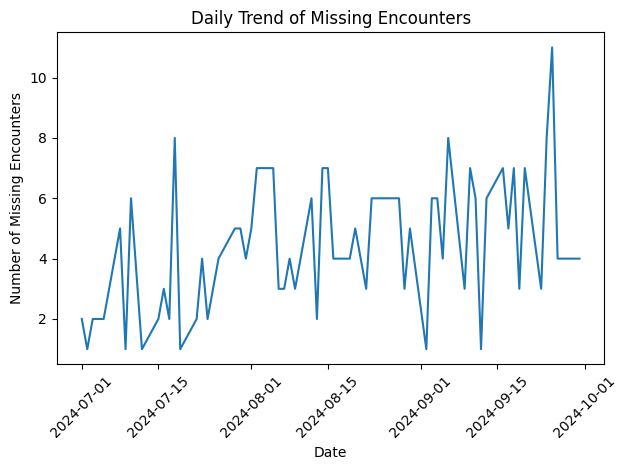

In [23]:
import matplotlib.pyplot as plt

daily_trend = (
    missing_encounters
    .groupby(missing_encounters['Date of Service'].dt.date)
    .size()
)

plt.figure()
plt.plot(daily_trend.index, daily_trend.values)
plt.title('Daily Trend of Missing Encounters')
plt.xlabel('Date')
plt.ylabel('Number of Missing Encounters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


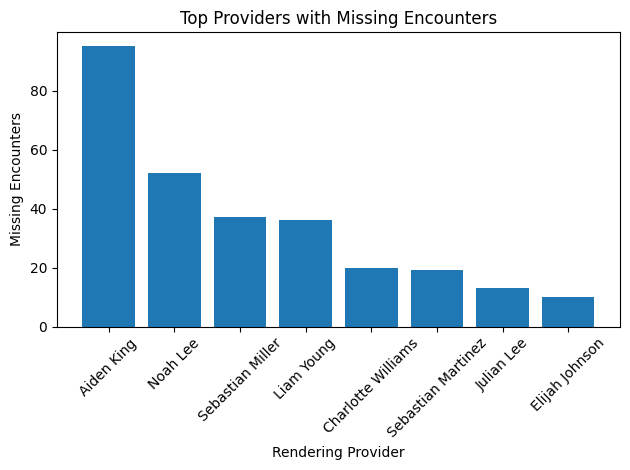

In [24]:
provider_missing = (
    missing_encounters['Provider Name']
    .value_counts()
    .head(10)
)

plt.figure()
plt.bar(provider_missing.index, provider_missing.values)
plt.title('Top Providers with Missing Encounters')
plt.xlabel('Rendering Provider')
plt.ylabel('Missing Encounters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
cpt_dist = missing_encounters['CPT Code'].value_counts().head(10)

print(cpt_dist)

CPT Code
{97112, 97140, 97010, TOS115, 97014, NORCM, 97110}    27
{97112, 97010, 97140, 97014, 97110, NORCM, SP}        24
{97010, 97110, 97112, 97140}                          21
{97112, 97140, 97010, 97110, G0283}                   16
{97112, 97010, 97140, NORCM, 97110}                   13
{97140, NORCM, 97112}                                 11
{97112, 97140, sp90, 97010, 97110, NORCM}             10
{NORCM, 97110, 97140}                                 10
{97112, 97140, 97010, sp90, 97014, 97110, NORCM}      10
{97140, 97035, 97014, 97010, 97110}                    9
Name: count, dtype: int64


In [26]:
ehr_grouped = ehr_grouped.copy()
missing_encounters = missing_encounters.copy()

ehr_grouped['Date of Service'] = pd.to_datetime(
    ehr_grouped['Date of Service'],
    errors='coerce'
)

missing_encounters['Date of Service'] = pd.to_datetime(
    missing_encounters['Date of Service'],
    errors='coerce'
)

In [27]:
ehr_monthly = (
    ehr_grouped
    .groupby(ehr_grouped['Date of Service'].dt.to_period('M'))
    .size()
)

missing_monthly = (
    missing_encounters
    .groupby(missing_encounters['Date of Service'].dt.to_period('M'))
    .size()
)

missing_rate = (missing_monthly / ehr_monthly * 100).dropna()


In [28]:
ehr_monthly = (
    ehr_grouped
    .groupby(ehr_grouped['Date of Service'].dt.to_period('M'))
    .size()
)

missing_monthly = (
    missing_encounters
    .groupby(missing_encounters['Date of Service'].dt.to_period('M'))
    .size()
)

missing_rate = (missing_monthly / ehr_monthly * 100).dropna()


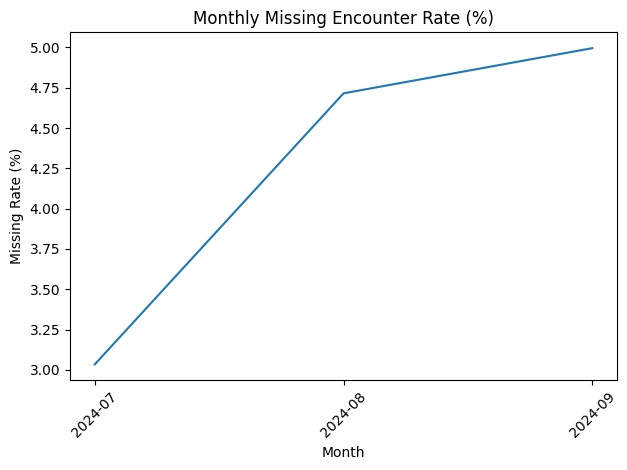

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(missing_rate.index.astype(str), missing_rate.values)
plt.title('Monthly Missing Encounter Rate (%)')
plt.xlabel('Month')
plt.ylabel('Missing Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


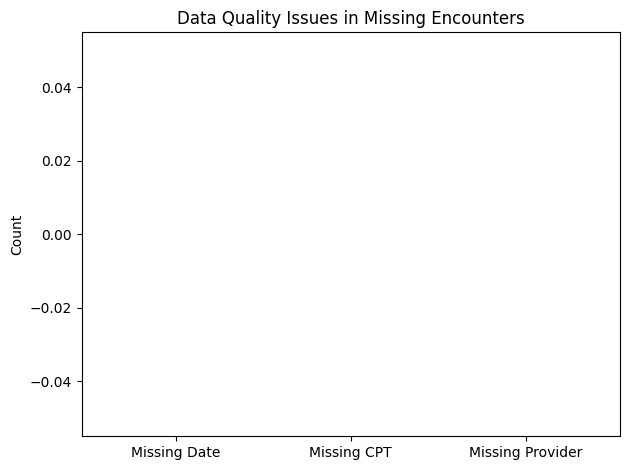

In [30]:
dq_issues = {
    'Missing Date': missing_encounters['Date of Service'].isna().sum(),
    'Missing CPT': missing_encounters['CPT Code'].isna().sum(),
    'Missing Provider': missing_encounters['Provider Name'].isna().sum()
}

plt.figure()
plt.bar(dq_issues.keys(), dq_issues.values())
plt.title('Data Quality Issues in Missing Encounters')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [31]:
missing_encounters = missing_encounters.copy()

missing_encounters['Date of Service'] = pd.to_datetime(
    missing_encounters['Date of Service'],
    errors='coerce'
)


In [32]:
missing_encounters['Unique ID'] = (
    missing_encounters['Patient Name'].str.strip() + ', ' +
    missing_encounters['Date of Service'].dt.strftime('%Y-%m-%d') + ', ' +
    missing_encounters['Provider Name'].str.strip()
)


In [33]:
final_missing_encounters = missing_encounters[['Unique ID']]


In [34]:
final_missing_encounters.to_csv(
    'missing_encounters_unique_id.csv',
    index=False
)


In [35]:
row_count = len(missing_encounters)
print(row_count)

282


In [36]:
comparison = ehr_grouped.merge(
    db[['encounter_key', 'cpt_codes']],
    on='encounter_key',
    how='left'
)


In [37]:
cpt_mismatch = comparison[
    comparison['cpt_codes'].notna() &
    (comparison['CPT Code'] != comparison['cpt_codes'])
]


In [38]:
cpt_mismatch.head()

,Patient Name,Provider Name,Date of Service,CPT Code,encounter_key,cpt_codes
0,Aiden Allen,Aiden King,2024-07-03,{97113},aiden allen_aiden king_07/03/2024,{97113}
1,Aiden Allen,Aiden King,2024-07-10,{97113},aiden allen_aiden king_07/10/2024,{97113}
2,Aiden Allen,Aiden King,2024-07-15,{97113},aiden allen_aiden king_07/15/2024,{97113}
3,Aiden Allen,Aiden King,2024-07-24,{97113},aiden allen_aiden king_07/24/2024,{97113}
4,Aiden Allen,Aiden King,2024-07-31,{97113},aiden allen_aiden king_07/31/2024,{97113}


In [39]:
comparison['cpt_issue'] = comparison.apply(
    lambda row: (
        'Missing in DB' if pd.isna(row['cpt_codes'])
        else 'CPT Mismatch' if row['CPT Code'] != row['cpt_codes']
        else 'Matched'
    ),
    axis=1
)


In [40]:
comparison['cpt_issue'].value_counts()


cpt_issue
CPT Mismatch     6438
Missing in DB     282
Name: count, dtype: int64

# cpt codes comparison

In [41]:
comparison = ehr_grouped.merge(
    db[['encounter_key', 'cpt_codes']],
    on='encounter_key',
    how='left'
)

comparison['cpt_match'] = comparison.apply(
    lambda row: row['CPT Code'] == row['cpt_codes']
    if isinstance(row['cpt_codes'], set) else False,
    axis=1
)


In [42]:
comparison.head()

,Patient Name,Provider Name,Date of Service,CPT Code,encounter_key,cpt_codes,cpt_match
0,Aiden Allen,Aiden King,2024-07-03,{97113},aiden allen_aiden king_07/03/2024,{97113},False
1,Aiden Allen,Aiden King,2024-07-10,{97113},aiden allen_aiden king_07/10/2024,{97113},False
2,Aiden Allen,Aiden King,2024-07-15,{97113},aiden allen_aiden king_07/15/2024,{97113},False
3,Aiden Allen,Aiden King,2024-07-24,{97113},aiden allen_aiden king_07/24/2024,{97113},False
4,Aiden Allen,Aiden King,2024-07-31,{97113},aiden allen_aiden king_07/31/2024,{97113},False


In [43]:
row_count = len(comparison)
print(row_count)

6720


In [44]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

# Load the datasets (update file paths as needed)
def load_datasets(ehr_file_path, imported_file_path):
    """
    Load the two CSV datasets
    """
    try:
        ehr_df = pd.read_csv(ehr_file_path)
        imported_df = pd.read_csv(imported_file_path)
        print(f"EHR Data loaded: {len(ehr_df)} records")
        print(f"Imported Data loaded: {len(imported_df)} records")
        return ehr_df, imported_df
    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        print("Please ensure the CSV files are in the correct directory.")
        return None, None
    except Exception as e:
        print(f"Error: {e}")
        return None, None

def preprocess_data(ehr_df, imported_df):
    """
    Clean and preprocess the data
    """
    # Make copies to avoid modifying original data
    ehr_clean = ehr_df.copy()
    imported_clean = imported_df.copy()
    
    # Convert date columns to datetime (adjust column names as needed)
    date_columns = ['Date of Service', 'Service Date', 'Date']
    
    for df in [ehr_clean, imported_clean]:
        # Find date column
        date_col = None
        for col in date_columns:
            if col in df.columns:
                date_col = col
                break
        
        if date_col:
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        
        # Clean text columns - strip whitespace
        text_columns = ['Patient Name', 'Rendering Provider', 'Provider']
        for col in text_columns:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.title()
    
    # Create unique ID for each encounter
    def create_encounter_id(df):
        # Try different column name combinations
        if all(col in df.columns for col in ['Patient Name', 'Date of Service', 'Rendering Provider']):
            # Handle date conversion to string safely
            date_str = df['Date of Service'].dt.strftime('%Y-%m-%d')
            df['Encounter_ID'] = df['Patient Name'] + '|' + date_str + '|' + df['Rendering Provider']
        elif all(col in df.columns for col in ['Patient Name', 'Service Date', 'Provider']):
            # Handle date conversion to string safely
            date_str = df['Service Date'].dt.strftime('%Y-%m-%d')
            df['Encounter_ID'] = df['Patient Name'] + '|' + date_str + '|' + df['Provider']
        else:
            # Use first three columns as fallback with safe date conversion
            col1 = df.iloc[:, 0].astype(str)
            col2 = df.iloc[:, 1]
            col3 = df.iloc[:, 2].astype(str)
            
            # Check if col2 is datetime and convert to string if needed
            if pd.api.types.is_datetime64_any_dtype(col2):
                col2 = col2.dt.strftime('%Y-%m-%d')
            else:
                col2 = col2.astype(str)
            
            df['Encounter_ID'] = col1 + '|' + col2 + '|' + col3
        return df
    
    ehr_clean = create_encounter_id(ehr_clean)
    imported_clean = create_encounter_id(imported_clean)
    
    return ehr_clean, imported_clean

def identify_missing_encounters(ehr_df, imported_df):
    """
    Identify encounters in EHR that are not in imported data
    """
    # Get all encounter IDs
    ehr_ids = set(ehr_df['Encounter_ID'])
    imported_ids = set(imported_df['Encounter_ID'])
    
    # Find missing encounters
    missing_ids = ehr_ids - imported_ids
    
    print(f"\nTotal EHR encounters: {len(ehr_ids)}")
    print(f"Total imported encounters: {len(imported_ids)}")
    print(f"Missing encounters: {len(missing_ids)}")
    print(f"Import success rate: {(len(imported_ids)/len(ehr_ids))*100:.2f}%")
    
    # Get detailed records for missing encounters
    missing_encounters = ehr_df[ehr_df['Encounter_ID'].isin(missing_ids)].copy()
    
    return missing_encounters, missing_ids

def analyze_missing_patterns(missing_df, ehr_df, imported_df):
    """
    Analyze patterns in missing encounters
    """
    print("\n" + "="*80)
    print("ANALYSIS OF MISSING ENCOUNTERS")
    print("="*80)
    
    analysis_results = {}
    
    # 1. Check for patterns by date
    if 'Date of Service' in missing_df.columns:
        missing_df['Month'] = missing_df['Date of Service'].dt.to_period('M')
        monthly_missing = missing_df['Month'].value_counts().sort_index()
        
        print("\n1. Monthly Distribution of Missing Encounters:")
        print("-" * 50)
        for month, count in monthly_missing.items():
            print(f"{month}: {count} missing encounters")
        
        analysis_results['monthly_pattern'] = monthly_missing
        
        # Check if there are specific problematic months
        if len(monthly_missing) > 0:
            max_month = monthly_missing.idxmax()
            max_count = monthly_missing.max()
            print(f"\nPeak month for missing encounters: {max_month} ({max_count} encounters)")
    
    # 2. Analyze by provider
    provider_col = 'Rendering Provider' if 'Rendering Provider' in missing_df.columns else 'Provider'
    
    if provider_col in missing_df.columns:
        provider_analysis = missing_df[provider_col].value_counts().head(10)
        
        print(f"\n2. Top 10 Providers with Missing Encounters:")
        print("-" * 50)
        for provider, count in provider_analysis.items():
            print(f"{provider}: {count} missing encounters")
        
        analysis_results['provider_pattern'] = provider_analysis
        
        # Calculate missing rate by provider
        provider_stats = {}
        for provider in missing_df[provider_col].unique():
            total_by_provider = ehr_df[ehr_df[provider_col] == provider].shape[0]
            missing_by_provider = missing_df[missing_df[provider_col] == provider].shape[0]
            if total_by_provider > 0:
                missing_rate = (missing_by_provider / total_by_provider) * 100
                provider_stats[provider] = {
                    'total': total_by_provider,
                    'missing': missing_by_provider,
                    'missing_rate': missing_rate
                }
        
        # Sort providers by missing rate
        high_missing_providers = sorted(
            [(provider, stats['missing_rate']) for provider, stats in provider_stats.items()],
            key=lambda x: x[1], reverse=True
        )[:5]
        
        print(f"\nTop 5 Providers by Missing Rate (%):")
        print("-" * 50)
        for provider, rate in high_missing_providers:
            print(f"{provider}: {rate:.2f}% missing")
    
    # 3. Check for data quality issues
    print("\n3. Data Quality Check:")
    print("-" * 50)
    
    # Check for null values in key columns
    key_columns = []
    for col in ['Patient Name', 'Date of Service', 'Rendering Provider', 'Patient', 'Provider', 'Service Date']:
        if col in missing_df.columns:
            key_columns.append(col)
    
    if key_columns:
        null_counts = missing_df[key_columns].isnull().sum()
        for col, count in null_counts.items():
            if count > 0:
                print(f"Column '{col}' has {count} null values in missing encounters")
    
    # 4. Procedure code analysis (if available)
    procedure_cols = [col for col in missing_df.columns if 'procedure' in col.lower() or 'code' in col.lower()]
    if procedure_cols:
        print(f"\n4. Procedure Code Analysis:")
        print("-" * 50)
        for proc_col in procedure_cols[:2]:  # Analyze first 2 procedure columns
            if proc_col in missing_df.columns:
                unique_procedures = missing_df[proc_col].nunique()
                print(f"Column '{proc_col}': {unique_procedures} unique values in missing encounters")
                
                # Check most common procedures in missing encounters
                common_procedures = missing_df[proc_col].value_counts().head(5)
                print(f"  Most common procedures in missing encounters:")
                for procedure, count in common_procedures.items():
                    print(f"    {procedure}: {count} times")
    
    return analysis_results

def generate_report(missing_encounters, analysis_results, output_dir='output'):
    """
    Generate output files with the results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Save missing encounters to CSV
    missing_file = os.path.join(output_dir, 'missing_encounters.csv')
    
    # Select relevant columns for output
    output_columns = []
    for col in ['Patient Name', 'Date of Service', 'Rendering Provider', 
                'Provider', 'Service Date', 'Encounter_ID']:
        if col in missing_encounters.columns:
            output_columns.append(col)
    
    if output_columns:
        missing_encounters[output_columns].to_csv(missing_file, index=False)
        print(f"\nMissing encounters saved to: {missing_file}")
    
    # 2. Save analysis summary
    summary_file = os.path.join(output_dir, 'analysis_summary.txt')
    with open(summary_file, 'w') as f:
        f.write("MISSING ENCOUNTERS ANALYSIS REPORT\n")
        f.write("="*50 + "\n\n")
        
        f.write(f"Total missing encounters: {len(missing_encounters)}\n\n")
        
        f.write("SUMMARY OF FINDINGS:\n")
        f.write("-"*30 + "\n")
        
        if 'monthly_pattern' in analysis_results:
            f.write("\nMonthly Pattern:\n")
            for month, count in analysis_results['monthly_pattern'].items():
                f.write(f"  {month}: {count} missing\n")
        
        if 'provider_pattern' in analysis_results:
            f.write("\nProvider Pattern (Top 10):\n")
            for provider, count in analysis_results['provider_pattern'].items():
                f.write(f"  {provider}: {count} missing\n")
    
    print(f"Analysis summary saved to: {summary_file}")
    
    # 3. Print quick insights
    print("\n" + "="*80)
    print("QUICK INSIGHTS:")
    print("="*80)
    print("1. Check if missing encounters cluster around specific dates")
    print("2. Identify providers with high missing encounter rates")
    print("3. Look for patterns in procedure codes or visit types")
    print("4. Verify data quality in source EHR system")
    print("5. Check for system outages or maintenance periods")

def main():
    """
    Main function to execute the analysis
    """
    print("CLOSED ENCOUNTERS ANALYSIS TOOL")
    print("="*60)
    
    # File paths - UPDATE THESE TO MATCH YOUR ACTUAL FILE NAMES
    ehr_file = "/kaggle/input/ehr-data/Ops Case Study Dataset - Sample EHR Data (2).csv"
    imported_file = "/kaggle/input/ehr-data/Ops Case Study Dataset - Sample DB Data (2) (1).csv"
    
    # Alternative file names (uncomment if needed)
    # ehr_file = "Client_EHR_Closed_Encounters.csv"
    # imported_file = "Imported_Closed_Encounters.csv"
    
    # Load data
    ehr_df, imported_df = load_datasets(ehr_file, imported_file)
    
    if ehr_df is None or imported_df is None:
        return
    
    # Preprocess data
    print("\nPreprocessing data...")
    ehr_clean, imported_clean = preprocess_data(ehr_df, imported_df)
    
    # Identify missing encounters
    print("\nIdentifying missing encounters...")
    missing_encounters, missing_ids = identify_missing_encounters(ehr_clean, imported_clean)
    
    if len(missing_encounters) == 0:
        print("\nSUCCESS: All encounters from EHR were successfully imported!")
        return
    
    # Analyze patterns
    analysis_results = analyze_missing_patterns(missing_encounters, ehr_clean, imported_clean)
    
    # Generate report
    generate_report(missing_encounters, analysis_results)
    
    # Display sample of missing encounters
    print("\n" + "="*80)
    print("SAMPLE OF MISSING ENCOUNTERS (first 10):")
    print("="*80)
    
    display_cols = []
    for col in ['Patient Name', 'Date of Service', 'Rendering Provider', 'Encounter_ID']:
        if col in missing_encounters.columns:
            display_cols.append(col)
    
    if display_cols:
        print(missing_encounters[display_cols].head(10).to_string(index=False))

if __name__ == "__main__":
    main()

CLOSED ENCOUNTERS ANALYSIS TOOL
EHR Data loaded: 25956 records
Imported Data loaded: 6482 records

Preprocessing data...

Identifying missing encounters...

Total EHR encounters: 6613
Total imported encounters: 6374
Missing encounters: 283
Import success rate: 96.39%

ANALYSIS OF MISSING ENCOUNTERS

1. Monthly Distribution of Missing Encounters:
--------------------------------------------------
2024-07: 299 missing encounters
2024-08: 524 missing encounters
2024-09: 527 missing encounters

Peak month for missing encounters: 2024-09 (527 encounters)

3. Data Quality Check:
--------------------------------------------------
Column 'Date of Service' has 2 null values in missing encounters

4. Procedure Code Analysis:
--------------------------------------------------
Column 'CPT Code': 26 unique values in missing encounters
  Most common procedures in missing encounters:
    97140: 258 times
    97110: 225 times
    NORCM: 203 times
    97112: 200 times
    97010: 178 times

Missing enco